# 📊 Exploratory Data Analysis — Fake Job Postings

**الهدف:** تحليل البيانات قبل وبعد التنظيف لفهم تأثير الـ Cleaning  
**Dataset:** Job Postings (Real vs Fraudulent)

---
### 🗂️ محتويات الـ Notebook

**🟠 Part 1 — Raw Data EDA**
1. تحميل الـ Raw Data
2. نظرة أولية (Shape, Types, Head)
3. تحليل القيم الناقصة
4. تحليل المتغير الهدف
5. تحليل الـ Binary Features
6. تحليل الـ Categorical Features
7. تحليل الـ Text Features

**🟣 Part 2 — Cleaned Data EDA**
8. تحميل الـ Cleaned Data
9. نظرة أولية بعد التنظيف
10. تحليل القيم الناقصة بعد التنظيف
11. تحليل الـ Features بعد التنظيف

**🔄 Part 3 — Before vs After Comparison**
12. مقارنة شاملة قبل وبعد التنظيف
13. ملخص النتائج

---
## ⚙️ Setup — المكتبات والإعدادات

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_style('whitegrid')
sns.set_palette('Set2')

COLOR_REAL  = '#2ecc71'
COLOR_FAKE  = '#e74c3c'
COLOR_RAW   = '#3498db'
COLOR_CLEAN = '#9b59b6'

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


---
# 🟠 PART 1 — Raw Data EDA

## 1️⃣ تحميل الـ Raw Data

In [27]:
raw = pd.read_csv('../data/raw/fake_job_postings.csv')
print(f'✅ Raw dataset loaded: {raw.shape[0]:,} rows × {raw.shape[1]} columns')

✅ Raw dataset loaded: 17,880 rows × 18 columns


## 2️⃣ نظرة أولية على الـ Raw Data

In [28]:
print('=' * 50)
print(f'  Shape   : {raw.shape[0]:,} rows  ×  {raw.shape[1]} columns')
print('=' * 50)
print('\n📋 Columns & Data Types:')
print(raw.dtypes.to_string())

  Shape   : 17,880 rows  ×  18 columns

📋 Columns & Data Types:
job_id                  int64
title                  object
location               object
department             object
salary_range           object
company_profile        object
description            object
requirements           object
benefits               object
telecommuting           int64
has_company_logo        int64
has_questions           int64
employment_type        object
required_experience    object
required_education     object
industry               object
function               object
fraudulent              int64


In [29]:
print('🔍 First 5 Rows:')
raw.head()

🔍 First 5 Rows:


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [30]:
print('📊 Statistical Summary:')
raw.describe()

📊 Statistical Summary:


,job_id,telecommuting,has_company_logo,has_questions,fraudulent
count,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000
mean,8940.500000,0.042897,0.795302,0.491723,0.048434
std,5161.655742,0.202631,0.403492,0.499945,0.214688
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,4470.750000,0.000000,1.000000,0.000000,0.000000
50%,8940.500000,0.000000,1.000000,0.000000,0.000000
75%,13410.250000,0.000000,1.000000,1.000000,0.000000
max,17880.000000,1.000000,1.000000,1.000000,1.000000


## 3️⃣ تحليل القيم الناقصة — Raw Data

⚠️  12 columns have missing values:

                     Missing Count  Missing %
salary_range                 15012      83.96
department                   11547      64.58
required_education            8105      45.33
benefits                      7212      40.34
required_experience           7050      39.43
function                      6455      36.10
industry                      4903      27.42
employment_type               3471      19.41
company_profile               3308      18.50
requirements                  2696      15.08
location                       346       1.94
description                      1       0.01


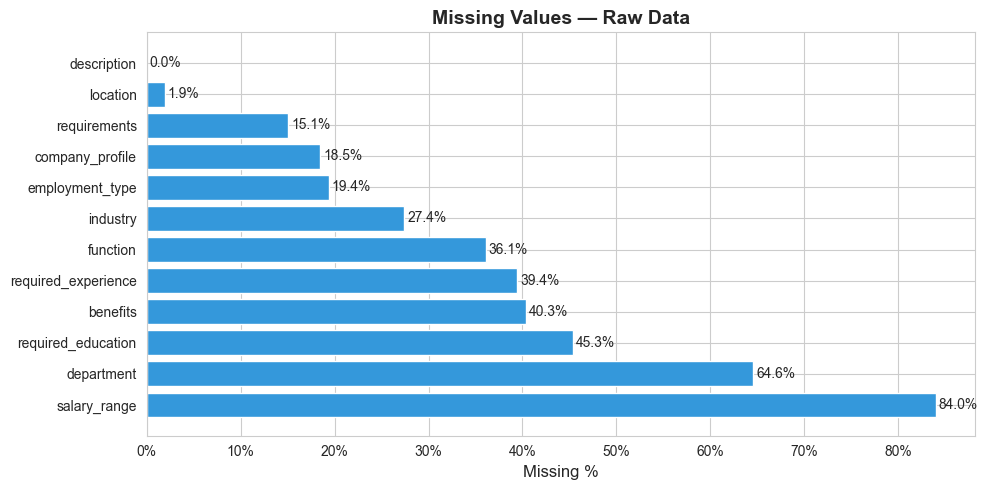

In [31]:
missing_raw = pd.DataFrame({
    'Missing Count': raw.isnull().sum(),
    'Missing %': (raw.isnull().sum() / len(raw) * 100).round(2)
}).sort_values('Missing %', ascending=False)

missing_raw_nonzero = missing_raw[missing_raw['Missing Count'] > 0]

print(f'⚠️  {len(missing_raw_nonzero)} columns have missing values:\n')
print(missing_raw_nonzero.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(missing_raw_nonzero.index, missing_raw_nonzero['Missing %'],
               color=COLOR_RAW, edgecolor='white')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Missing %')
ax.set_title('Missing Values — Raw Data', fontweight='bold')
for bar, val in zip(bars, missing_raw_nonzero['Missing %']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)
plt.tight_layout()
plt.show()

## 4️⃣ تحليل المتغير الهدف — Raw Data

📊 Target Distribution (Raw):
          Count  Percentage
Real (0)  17014       95.16
Fake (1)    866        4.84


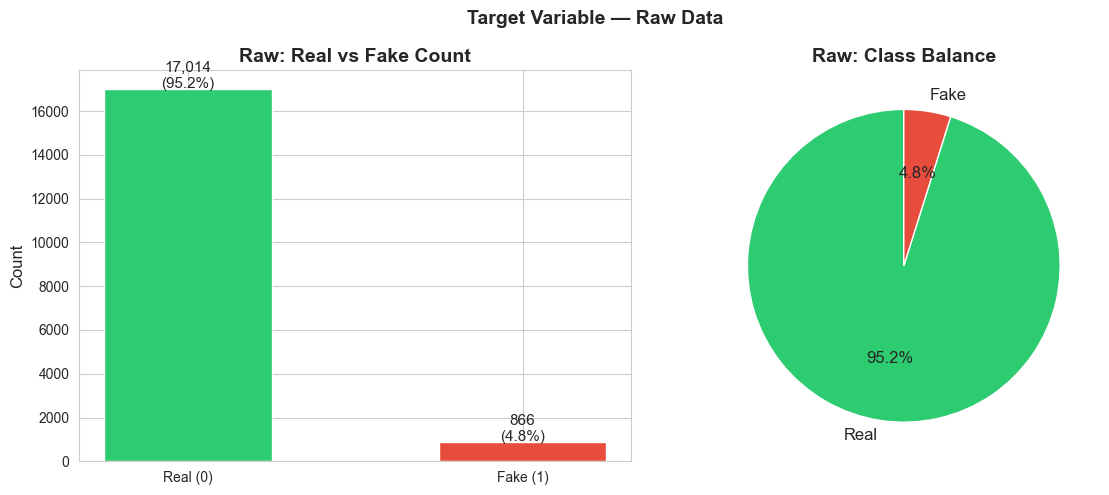


⚠️  Imbalance Ratio → Real : Fake = 19.6 : 1


In [32]:
target_raw = raw['fraudulent'].value_counts()
target_raw_pct = raw['fraudulent'].value_counts(normalize=True) * 100

print('📊 Target Distribution (Raw):')
summary = pd.DataFrame({'Count': target_raw, 'Percentage': target_raw_pct.round(2)})
summary.index = ['Real (0)', 'Fake (1)']
print(summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['Real (0)', 'Fake (1)'], target_raw,
            color=[COLOR_REAL, COLOR_FAKE], edgecolor='white', width=0.5)
axes[0].set_title('Raw: Real vs Fake Count', fontweight='bold')
axes[0].set_ylabel('Count')
for i, (cnt, pct) in enumerate(zip(target_raw, target_raw_pct)):
    axes[0].text(i, cnt + 50, f'{cnt:,}\n({pct:.1f}%)', ha='center', fontsize=11)

axes[1].pie(target_raw, labels=['Real', 'Fake'],
            colors=[COLOR_REAL, COLOR_FAKE],
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Raw: Class Balance', fontweight='bold')

plt.suptitle('Target Variable — Raw Data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n⚠️  Imbalance Ratio → Real : Fake = {target_raw[0]/target_raw[1]:.1f} : 1')

## 5️⃣ تحليل الـ Binary Features — Raw Data

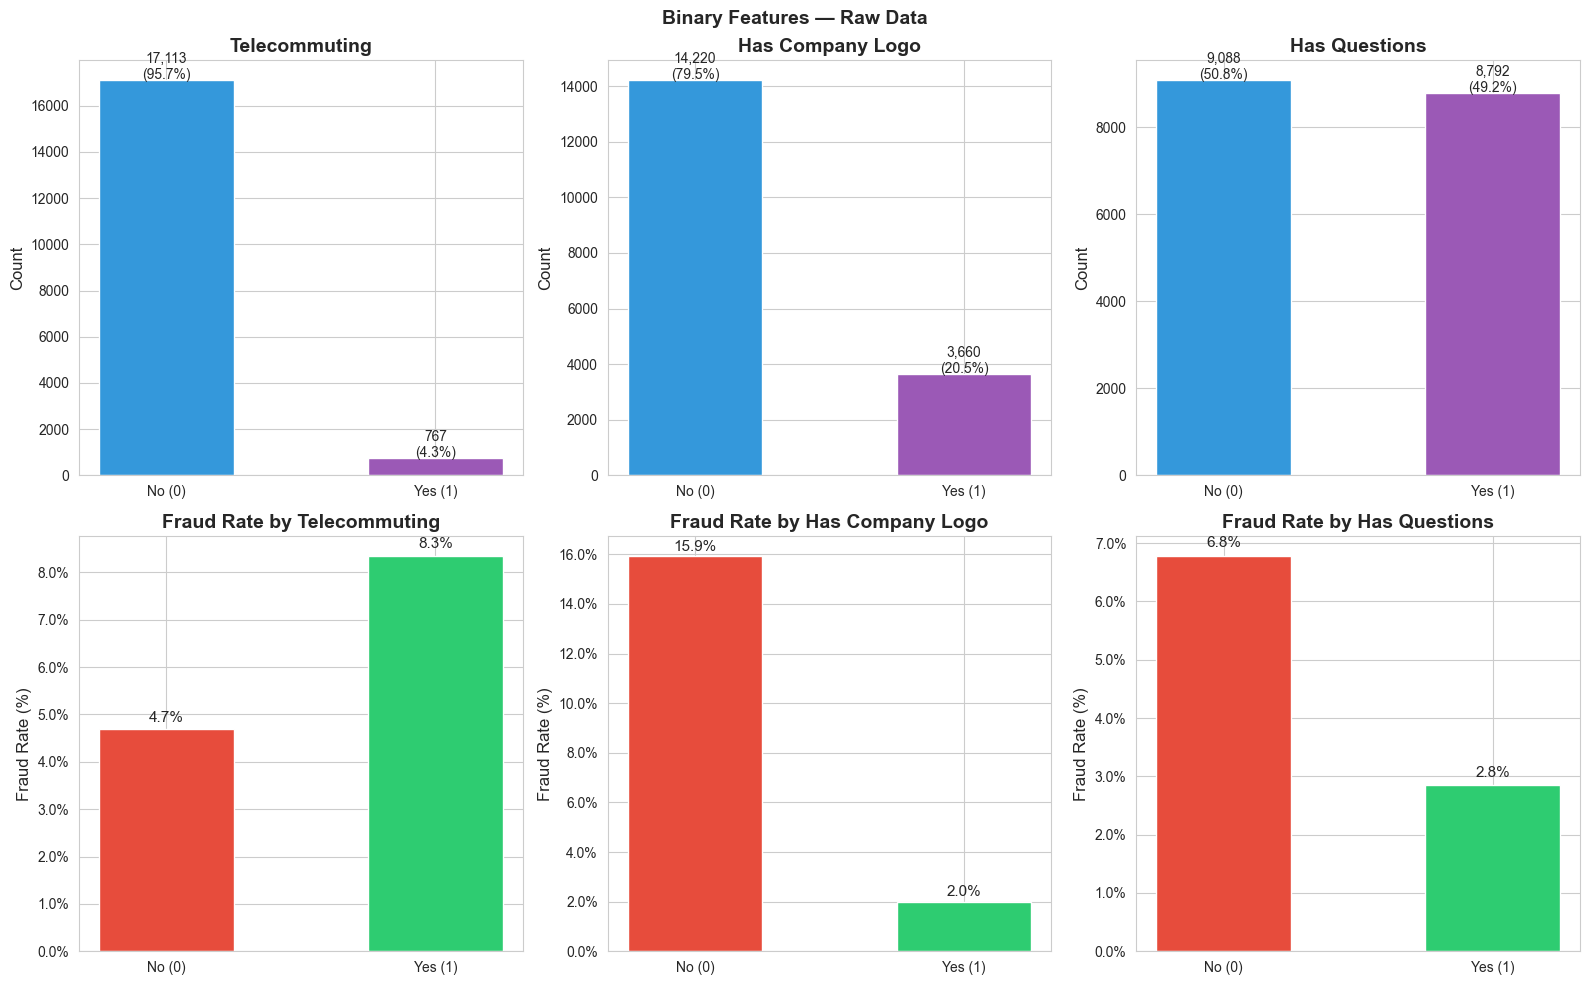

In [33]:
binary_cols = ['telecommuting', 'has_company_logo', 'has_questions']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for i, col in enumerate(binary_cols):
    counts = raw[col].value_counts()
    pct    = raw[col].value_counts(normalize=True) * 100
    axes[0, i].bar(['No (0)', 'Yes (1)'], counts,
                   color=[COLOR_RAW, COLOR_CLEAN], edgecolor='white', width=0.5)
    axes[0, i].set_title(col.replace('_', ' ').title(), fontweight='bold')
    axes[0, i].set_ylabel('Count')
    for j, (cnt, p) in enumerate(zip(counts, pct)):
        axes[0, i].text(j, cnt + 30, f'{cnt:,}\n({p:.1f}%)', ha='center', fontsize=10)

    fraud_rate = raw.groupby(col)['fraudulent'].mean() * 100
    axes[1, i].bar(['No (0)', 'Yes (1)'], fraud_rate,
                   color=[COLOR_FAKE, COLOR_REAL], edgecolor='white', width=0.5)
    axes[1, i].set_title(f'Fraud Rate by {col.replace("_", " ").title()}', fontweight='bold')
    axes[1, i].set_ylabel('Fraud Rate (%)')
    axes[1, i].yaxis.set_major_formatter(mtick.PercentFormatter())
    for j, val in enumerate(fraud_rate):
        axes[1, i].text(j, val + 0.1, f'{val:.1f}%', ha='center', va='bottom', fontsize=11)

plt.suptitle('Binary Features — Raw Data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6️⃣ تحليل الـ Categorical Features — Raw Data

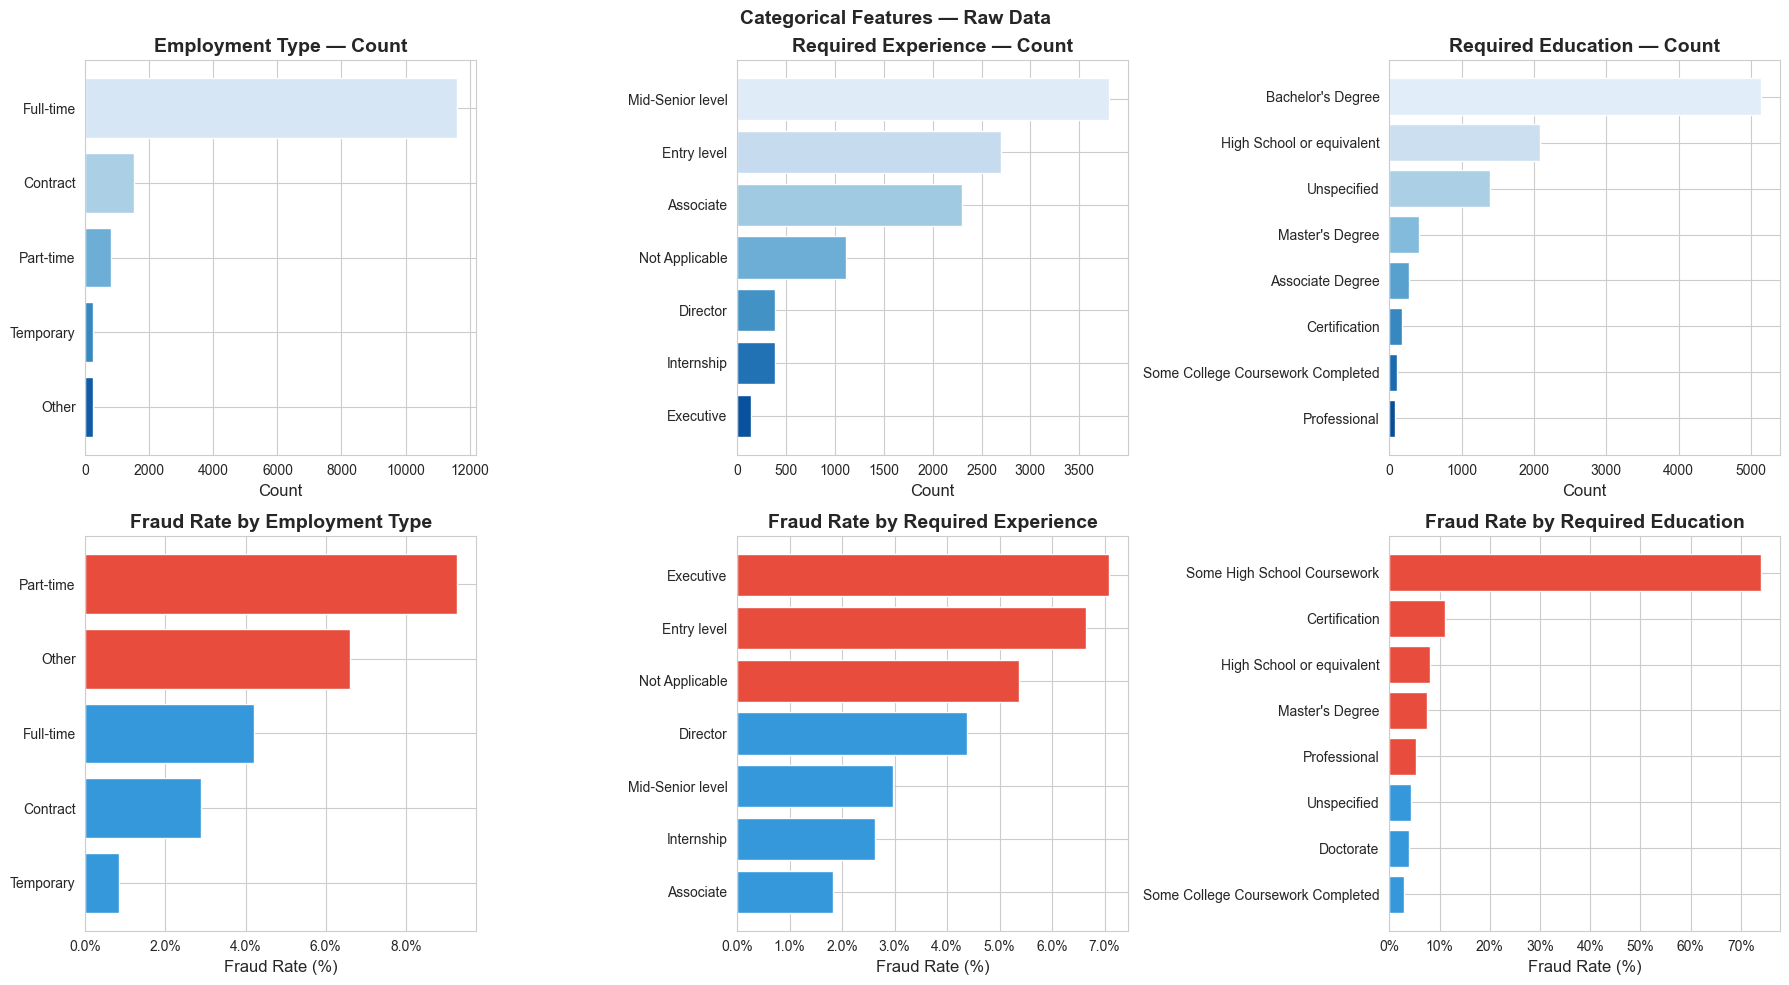

In [34]:
cat_cols = ['employment_type', 'required_experience', 'required_education']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, col in enumerate(cat_cols):
    top = raw[col].value_counts().head(8)
    axes[0, i].barh(top.index[::-1], top.values[::-1],
                    color=sns.color_palette('Blues_r', len(top)), edgecolor='white')
    axes[0, i].set_title(f'{col.replace("_"," ").title()} — Count', fontweight='bold')
    axes[0, i].set_xlabel('Count')

    fraud_rate = (
        raw.groupby(col)['fraudulent'].mean().mul(100)
        .sort_values(ascending=True).tail(8)
    )
    colors = [COLOR_FAKE if v > 5 else COLOR_RAW for v in fraud_rate]
    axes[1, i].barh(fraud_rate.index, fraud_rate.values, color=colors, edgecolor='white')
    axes[1, i].set_title(f'Fraud Rate by {col.replace("_"," ").title()}', fontweight='bold')
    axes[1, i].set_xlabel('Fraud Rate (%)')
    axes[1, i].xaxis.set_major_formatter(mtick.PercentFormatter())

plt.suptitle('Categorical Features — Raw Data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7️⃣ تحليل الـ Text Features — Raw Data

In [35]:
text_cols = ['title', 'company_profile', 'description', 'requirements', 'benefits']

for col in text_cols:
    raw[f'{col}_len'] = raw[col].astype(str).apply(len)

print('📏 Text Length Statistics (Raw):')
raw[[f'{c}_len' for c in text_cols]].describe().round(0)

📏 Text Length Statistics (Raw):


,title_len,company_profile_len,description_len,requirements_len,benefits_len
count,17880.0,17880.0,17880.0,17880.0,17880.0
mean,29.0,621.0,1218.0,591.0,210.0
std,14.0,567.0,895.0,613.0,336.0
min,3.0,3.0,3.0,1.0,1.0
25%,19.0,138.0,607.0,146.0,3.0
50%,25.0,570.0,1017.0,467.0,45.0
75%,35.0,879.0,1586.0,820.0,294.0
max,142.0,6178.0,14907.0,10864.0,4429.0


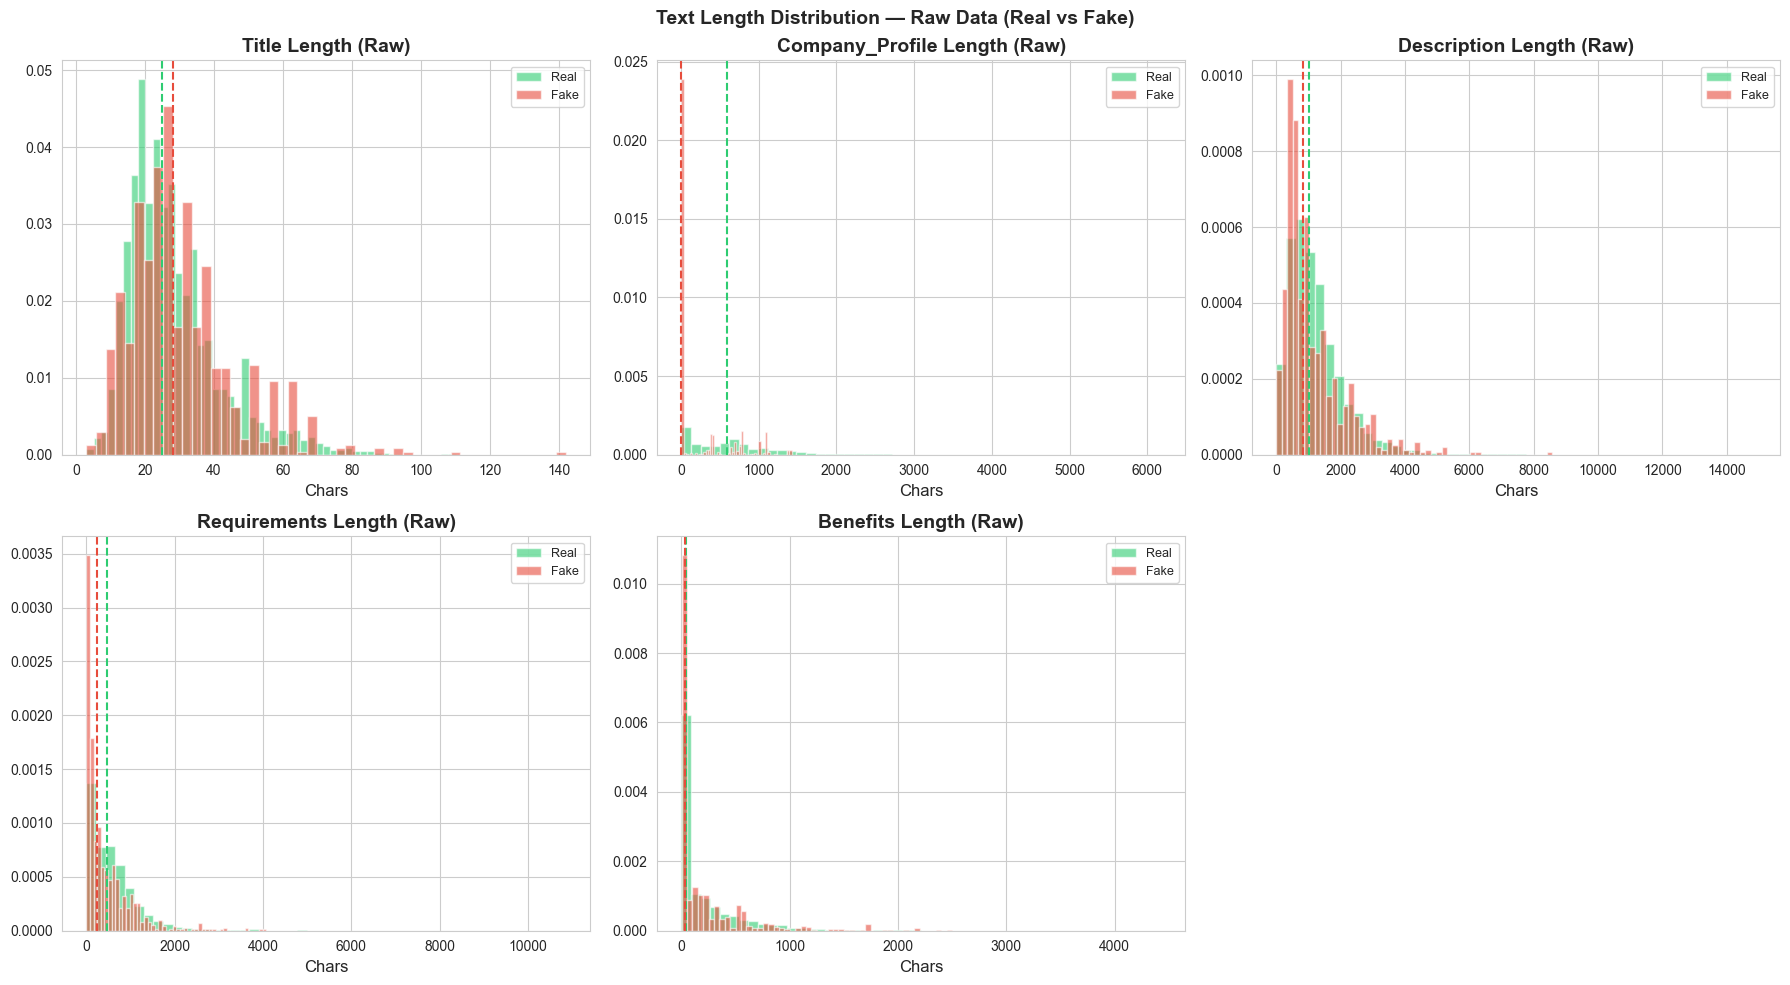

In [36]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(text_cols):
    ax = axes[i]
    real_vals = raw[raw['fraudulent'] == 0][f'{col}_len']
    fake_vals = raw[raw['fraudulent'] == 1][f'{col}_len']
    ax.hist(real_vals, bins=50, alpha=0.6, color=COLOR_REAL, label='Real', density=True)
    ax.hist(fake_vals, bins=50, alpha=0.6, color=COLOR_FAKE, label='Fake', density=True)
    ax.axvline(real_vals.median(), color=COLOR_REAL, linestyle='--', linewidth=1.5)
    ax.axvline(fake_vals.median(), color=COLOR_FAKE, linestyle='--', linewidth=1.5)
    ax.set_title(f'{col.title()} Length (Raw)', fontweight='bold')
    ax.set_xlabel('Chars')
    ax.legend(fontsize=9)

axes[-1].axis('off')
plt.suptitle('Text Length Distribution — Raw Data (Real vs Fake)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
# 🟣 PART 2 — Cleaned Data EDA

## 8️⃣ تحميل الـ Cleaned Data

In [37]:
df = pd.read_csv('../data/processed/cleaned_data.csv')
print(f'✅ Cleaned dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')

✅ Cleaned dataset loaded: 17,533 rows × 17 columns


## 9️⃣ نظرة أولية بعد التنظيف

In [38]:
print('=' * 50)
print(f'  Shape   : {df.shape[0]:,} rows  ×  {df.shape[1]} columns')
print('=' * 50)
print('\n📋 Columns & Data Types:')
print(df.dtypes.to_string())

  Shape   : 17,533 rows  ×  17 columns

📋 Columns & Data Types:
title                  object
location               object
department             object
salary_range           object
company_profile        object
description            object
requirements           object
benefits               object
telecommuting           int64
has_company_logo        int64
has_questions           int64
employment_type        object
required_experience    object
required_education     object
industry               object
function               object
fraudulent              int64


In [39]:
print('🔍 First 5 Rows (Cleaned):')
df.head()

🔍 First 5 Rows (Cleaned):


,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,Marketing Intern,"US, NY, New York",Marketing,Not Specified,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,Not Specified,Not Specified,Marketing,0
1,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,Not Specified,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,Not Specified,Marketing and Advertising,Customer Service,0
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",Unknown,Not Specified,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,Not Specified,Not Specified,Not Specified,Not Specified,Not Specified,0
3,Account Executive - Washington DC,"US, DC, Washington",Sales,Not Specified,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,Bill Review Manager,"US, FL, Fort Worth",Unknown,Not Specified,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


## 🔟 تحليل القيم الناقصة — Cleaned Data

In [40]:
missing_clean = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing %', ascending=False)

missing_clean_nonzero = missing_clean[missing_clean['Missing Count'] > 0]

if missing_clean_nonzero.empty:
    print('✅ No missing values — dataset is fully clean!')
else:
    print(f'⚠️  {len(missing_clean_nonzero)} columns still have missing values:')
    print(missing_clean_nonzero.to_string())

⚠️  3 columns still have missing values:
                 Missing Count  Missing %
benefits                  6961      39.70
company_profile           3245      18.51
requirements              2519      14.37


## 1️⃣1️⃣ تحليل الـ Features — Cleaned Data

📊 Target Distribution (Cleaned):
          Count  Percentage
Real (0)  16687       95.17
Fake (1)    846        4.83


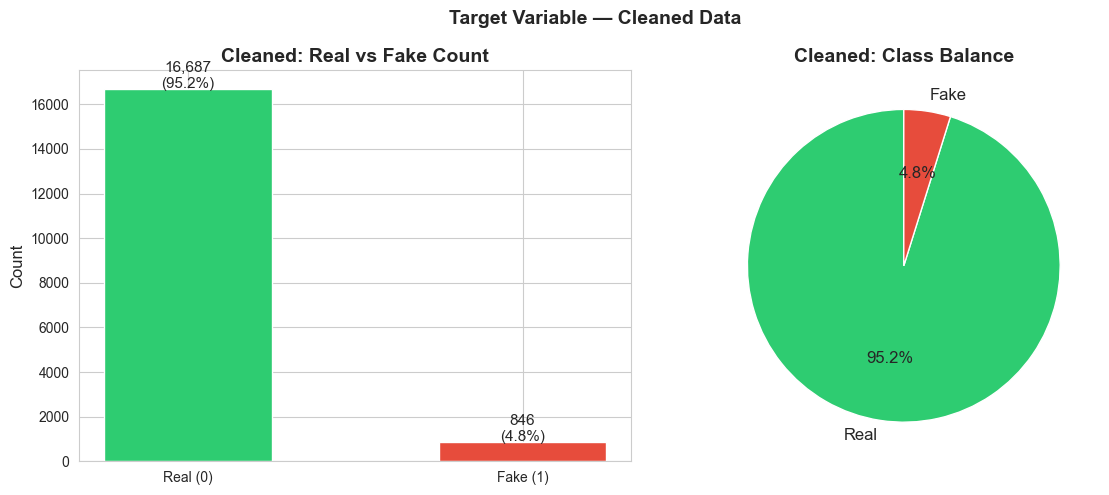

In [41]:
# Target Distribution
target_clean = df['fraudulent'].value_counts()
target_clean_pct = df['fraudulent'].value_counts(normalize=True) * 100

print('📊 Target Distribution (Cleaned):')
summary_c = pd.DataFrame({'Count': target_clean, 'Percentage': target_clean_pct.round(2)})
summary_c.index = ['Real (0)', 'Fake (1)']
print(summary_c)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(['Real (0)', 'Fake (1)'], target_clean,
            color=[COLOR_REAL, COLOR_FAKE], edgecolor='white', width=0.5)
axes[0].set_title('Cleaned: Real vs Fake Count', fontweight='bold')
axes[0].set_ylabel('Count')
for i, (cnt, pct) in enumerate(zip(target_clean, target_clean_pct)):
    axes[0].text(i, cnt + 50, f'{cnt:,}\n({pct:.1f}%)', ha='center', fontsize=11)

axes[1].pie(target_clean, labels=['Real', 'Fake'],
            colors=[COLOR_REAL, COLOR_FAKE],
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Cleaned: Class Balance', fontweight='bold')

plt.suptitle('Target Variable — Cleaned Data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

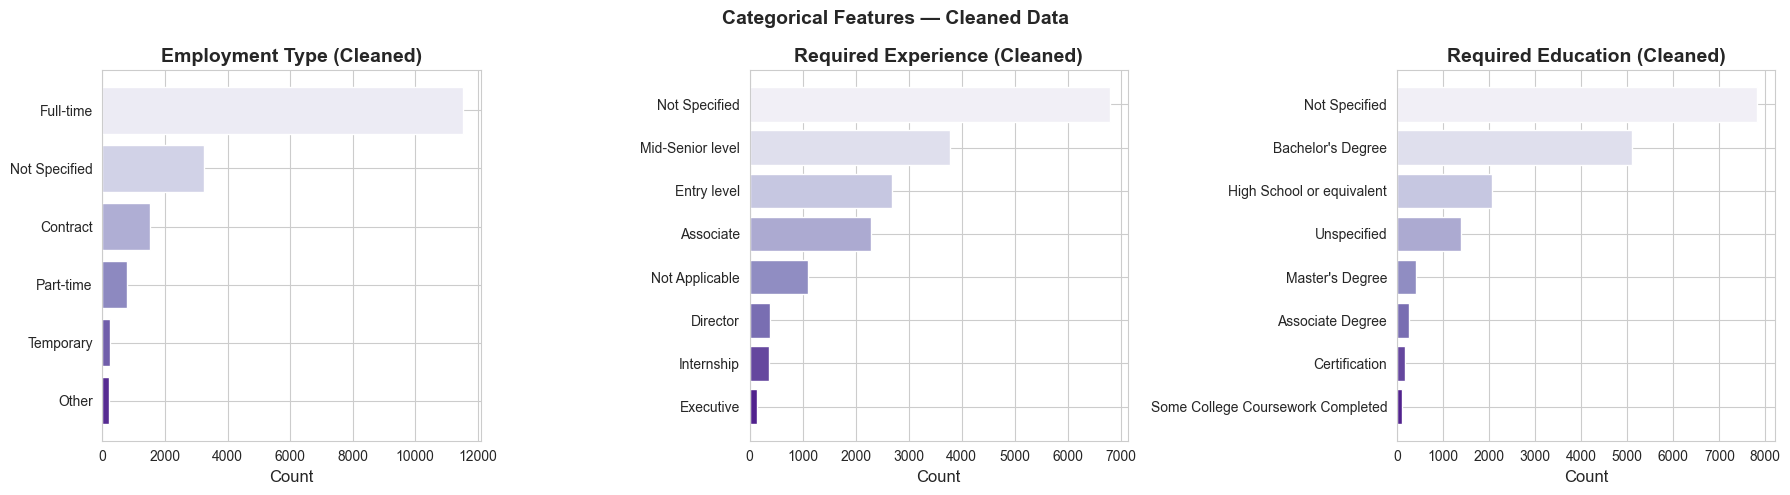

In [42]:
# Categorical Features
cat_cols = ['employment_type', 'required_experience', 'required_education']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, cat_cols):
    top = df[col].value_counts().head(8)
    ax.barh(top.index[::-1], top.values[::-1],
            color=sns.color_palette('Purples_r', len(top)), edgecolor='white')
    ax.set_title(f'{col.replace("_"," ").title()} (Cleaned)', fontweight='bold')
    ax.set_xlabel('Count')

plt.suptitle('Categorical Features — Cleaned Data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [43]:
# Text Lengths
text_cols = ['title', 'company_profile', 'description', 'requirements', 'benefits']
for col in text_cols:
    df[f'{col}_len'] = df[col].astype(str).apply(len)

print('📏 Text Length Statistics (Cleaned):')
df[[f'{c}_len' for c in text_cols]].describe().round(0)

📏 Text Length Statistics (Cleaned):


,title_len,company_profile_len,description_len,requirements_len,benefits_len
count,17533.0,17533.0,17533.0,17533.0,17533.0
mean,29.0,623.0,1221.0,595.0,212.0
std,14.0,568.0,896.0,613.0,337.0
min,3.0,3.0,6.0,1.0,1.0
25%,19.0,134.0,609.0,150.0,3.0
50%,26.0,570.0,1020.0,471.0,49.0
75%,35.0,879.0,1591.0,827.0,299.0
max,142.0,6178.0,14907.0,10864.0,4429.0


---
# 🔄 PART 3 — Before vs After Comparison

## 1️⃣2️⃣ مقارنة شاملة — Before vs After

In [44]:
print('📦 Shape Comparison:')
print(f'  Raw     → {raw.shape[0]:,} rows × {raw.shape[1]} columns')
print(f'  Cleaned → {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'  Rows removed: {raw.shape[0] - df.shape[0]:,}  ({(raw.shape[0]-df.shape[0])/raw.shape[0]*100:.2f}%)')

📦 Shape Comparison:
  Raw     → 17,880 rows × 23 columns
  Cleaned → 17,533 rows × 22 columns
  Rows removed: 347  (1.94%)


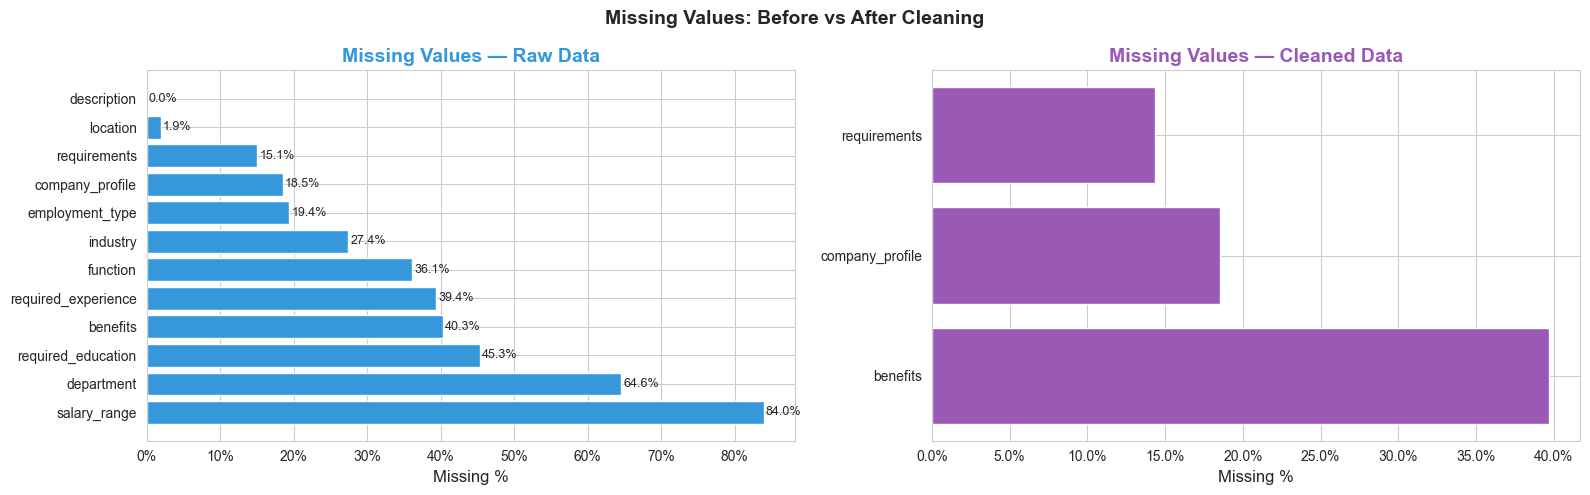

In [45]:
# مقارنة Missing Values
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(missing_raw_nonzero.index, missing_raw_nonzero['Missing %'],
             color=COLOR_RAW, edgecolor='white')
axes[0].set_title('Missing Values — Raw Data', fontweight='bold', color=COLOR_RAW)
axes[0].set_xlabel('Missing %')
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter())
for i, val in enumerate(missing_raw_nonzero['Missing %']):
    axes[0].text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=9)

if missing_clean_nonzero.empty:
    axes[1].text(0.5, 0.5, '✅ No Missing Values!', ha='center', va='center',
                 fontsize=16, color=COLOR_CLEAN, transform=axes[1].transAxes, fontweight='bold')
    axes[1].set_title('Missing Values — Cleaned Data', fontweight='bold', color=COLOR_CLEAN)
else:
    axes[1].barh(missing_clean_nonzero.index, missing_clean_nonzero['Missing %'],
                 color=COLOR_CLEAN, edgecolor='white')
    axes[1].set_title('Missing Values — Cleaned Data', fontweight='bold', color=COLOR_CLEAN)
    axes[1].set_xlabel('Missing %')
    axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())

plt.suptitle('Missing Values: Before vs After Cleaning', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

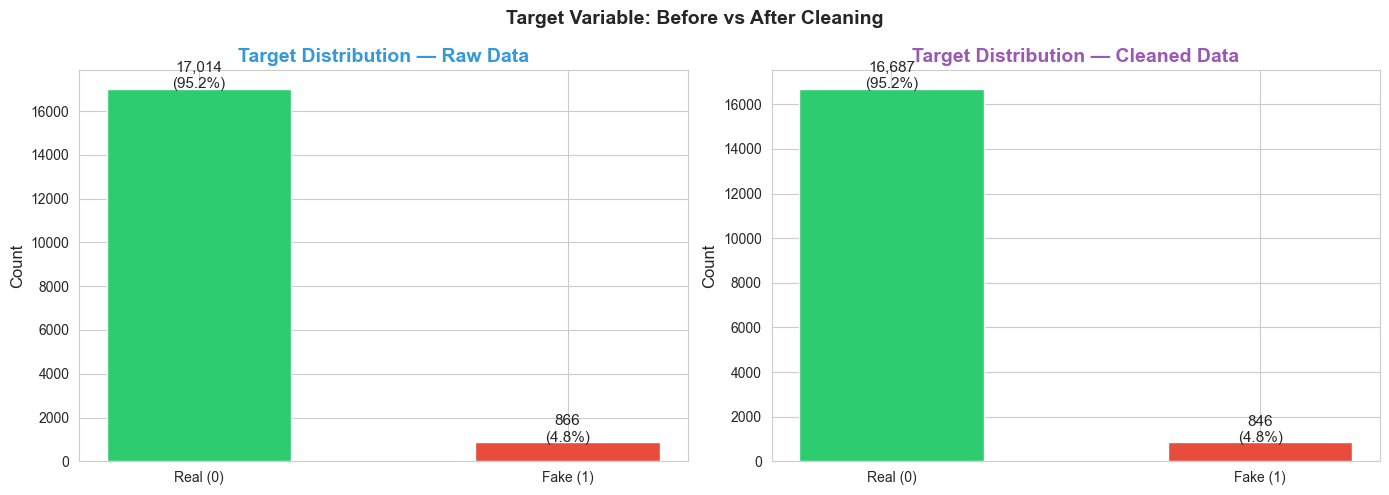

In [46]:
# مقارنة Target Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, title, color in [
    (axes[0], raw, 'Raw Data',     COLOR_RAW),
    (axes[1], df,  'Cleaned Data', COLOR_CLEAN)
]:
    counts = data['fraudulent'].value_counts()
    pcts   = data['fraudulent'].value_counts(normalize=True) * 100
    ax.bar(['Real (0)', 'Fake (1)'], counts,
           color=[COLOR_REAL, COLOR_FAKE], edgecolor='white', width=0.5)
    ax.set_title(f'Target Distribution — {title}', fontweight='bold', color=color)
    ax.set_ylabel('Count')
    for i, (cnt, pct) in enumerate(zip(counts, pcts)):
        ax.text(i, cnt + 30, f'{cnt:,}\n({pct:.1f}%)', ha='center', fontsize=11)

plt.suptitle('Target Variable: Before vs After Cleaning', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

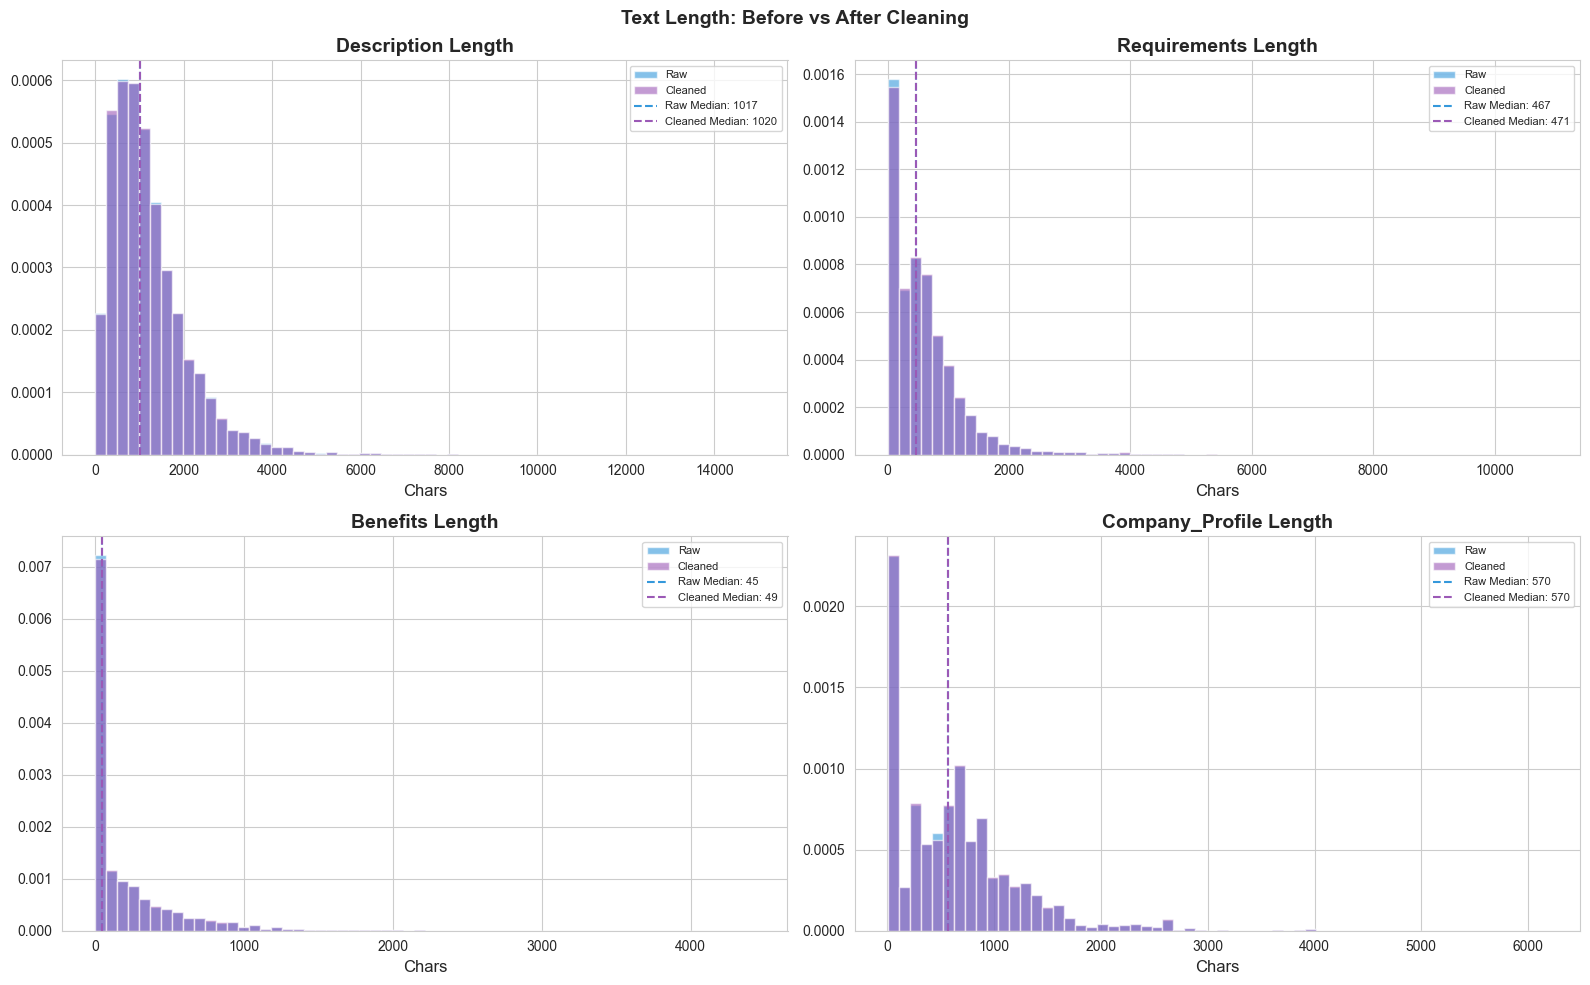

In [47]:
# مقارنة Text Lengths
compare_text = ['description', 'requirements', 'benefits', 'company_profile']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(compare_text):
    ax = axes[i]
    raw_len   = raw[col].astype(str).apply(len)
    clean_len = df[col].astype(str).apply(len)
    ax.hist(raw_len,   bins=60, alpha=0.6, color=COLOR_RAW,   label='Raw',     density=True)
    ax.hist(clean_len, bins=60, alpha=0.6, color=COLOR_CLEAN, label='Cleaned', density=True)
    ax.axvline(raw_len.median(),   color=COLOR_RAW,   linestyle='--', linewidth=1.5,
               label=f'Raw Median: {raw_len.median():.0f}')
    ax.axvline(clean_len.median(), color=COLOR_CLEAN, linestyle='--', linewidth=1.5,
               label=f'Cleaned Median: {clean_len.median():.0f}')
    ax.set_title(f'{col.title()} Length', fontweight='bold')
    ax.set_xlabel('Chars')
    ax.legend(fontsize=8)

plt.suptitle('Text Length: Before vs After Cleaning', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

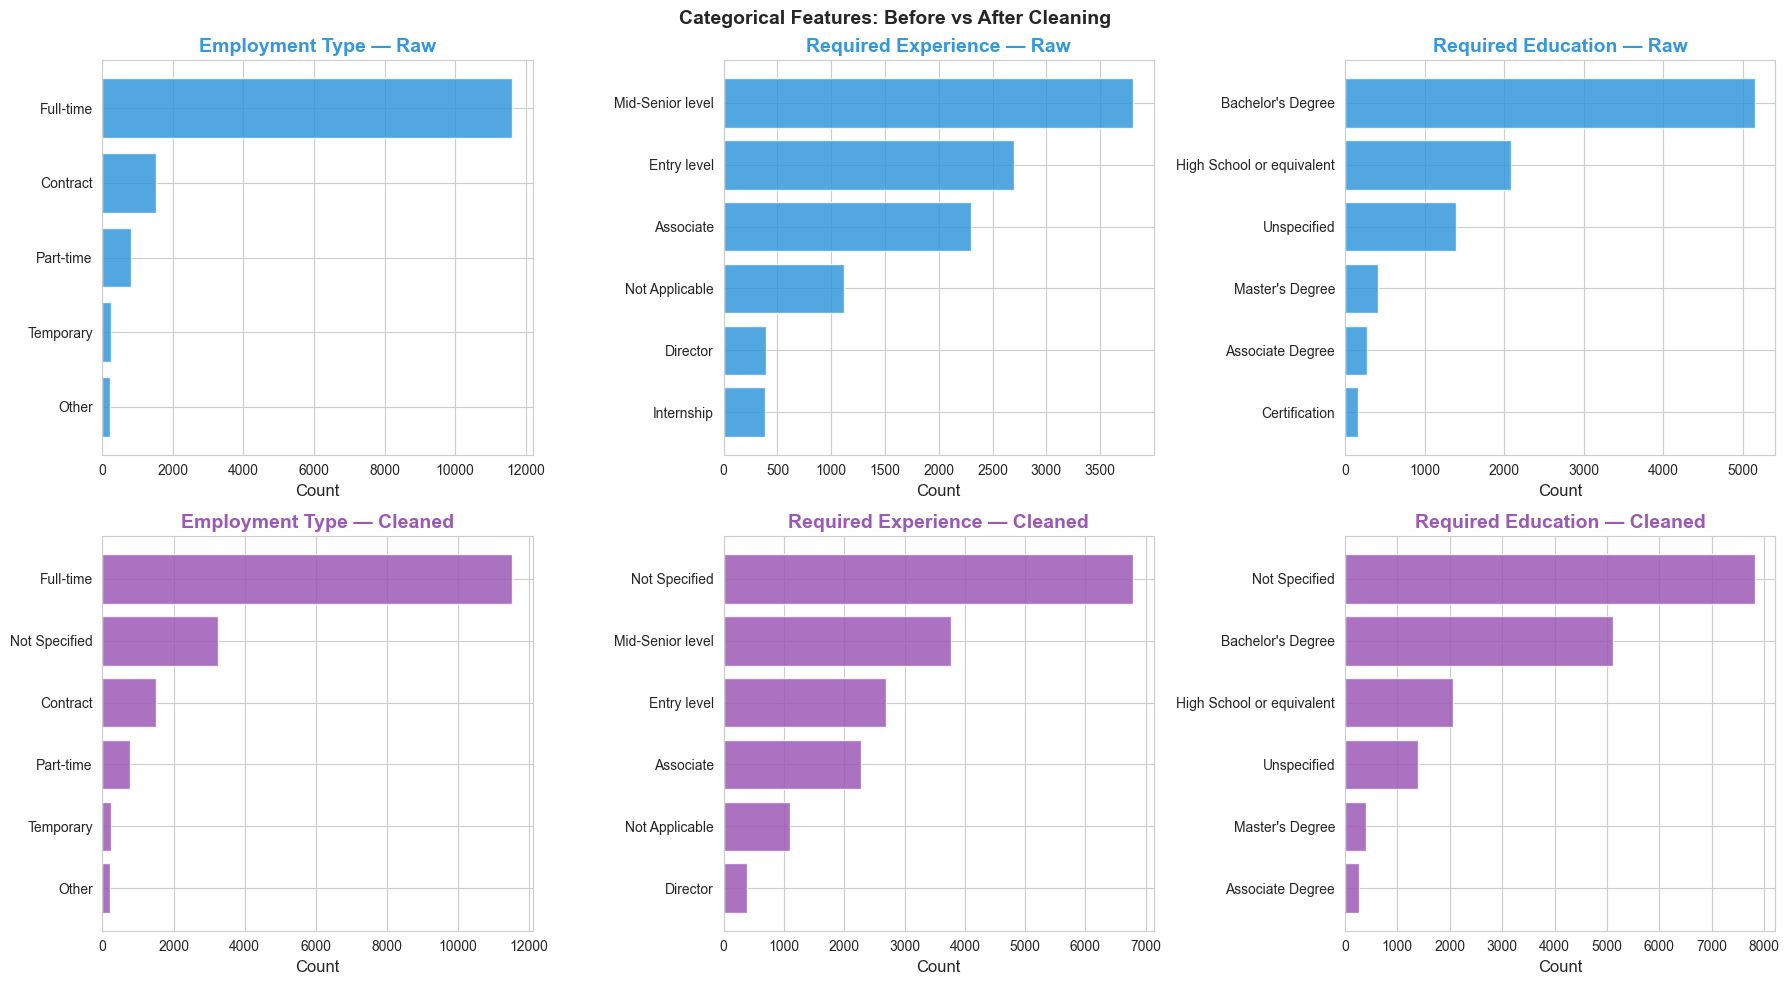

In [48]:
# مقارنة Categorical Features
cat_cols = ['employment_type', 'required_experience', 'required_education']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, col in enumerate(cat_cols):
    top_raw   = raw[col].value_counts().head(6)
    top_clean = df[col].value_counts().head(6)

    axes[0, i].barh(top_raw.index[::-1], top_raw.values[::-1],
                    color=COLOR_RAW, edgecolor='white', alpha=0.85)
    axes[0, i].set_title(f'{col.replace("_"," ").title()} — Raw',
                         fontweight='bold', color=COLOR_RAW)
    axes[0, i].set_xlabel('Count')

    axes[1, i].barh(top_clean.index[::-1], top_clean.values[::-1],
                    color=COLOR_CLEAN, edgecolor='white', alpha=0.85)
    axes[1, i].set_title(f'{col.replace("_"," ").title()} — Cleaned',
                         fontweight='bold', color=COLOR_CLEAN)
    axes[1, i].set_xlabel('Count')

plt.suptitle('Categorical Features: Before vs After Cleaning', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 1️⃣3️⃣ ملخص النتائج

In [49]:
raw_fraud   = raw['fraudulent'].sum()
raw_real    = len(raw) - raw_fraud
clean_fraud = df['fraudulent'].sum()
clean_real  = len(df) - clean_fraud

print('=' * 60)
print('           📋 EDA SUMMARY REPORT')
print('=' * 60)

print('\n📦 Dataset Size:')
print(f'  Raw     → {len(raw):,} rows  |  Real: {raw_real:,}  |  Fake: {raw_fraud:,}')
print(f'  Cleaned → {len(df):,} rows  |  Real: {clean_real:,}  |  Fake: {clean_fraud:,}')
print(f'  Removed → {len(raw)-len(df):,} rows ({(len(raw)-len(df))/len(raw)*100:.2f}%)')

print('\n🔍 Missing Values:')
print(f'  Raw     → {len(missing_raw_nonzero)} columns had missing values')
print(f'  Cleaned → {len(missing_clean_nonzero)} columns with missing values')

print('\n⚖️  Class Imbalance:')
print(f'  Raw     → Real:Fake = {raw_real/raw_fraud:.1f} : 1')
print(f'  Cleaned → Real:Fake = {clean_real/clean_fraud:.1f} : 1')

logo_raw   = raw[raw['has_company_logo'] == 0]['fraudulent'].mean() * 100
logo_clean = df[df['has_company_logo'] == 0]['fraudulent'].mean() * 100
print('\n🔑 Key Findings:')
print(f'  • Jobs WITHOUT logo → Fraud Rate: Raw {logo_raw:.1f}%  |  Cleaned {logo_clean:.1f}%')

for dataset, label in [(raw, 'Raw'), (df, 'Cleaned')]:
    r = dataset[dataset['fraudulent']==0]['description'].astype(str).apply(len).median()
    f = dataset[dataset['fraudulent']==1]['description'].astype(str).apply(len).median()
    print(f'  • Description length ({label}) → Real: {r:.0f} chars | Fake: {f:.0f} chars')

print('\n📝 Recommended Next Steps:')
print('  1. Feature Engineering (text length, keyword flags, etc.)')
print('  2. Text Vectorization (TF-IDF / Word Embeddings)')
print('  3. Handle Class Imbalance (SMOTE or class_weight)')
print('  4. Build baseline ML model')
print('=' * 60)

           📋 EDA SUMMARY REPORT

📦 Dataset Size:
  Raw     → 17,880 rows  |  Real: 17,014  |  Fake: 866
  Cleaned → 17,533 rows  |  Real: 16,687  |  Fake: 846
  Removed → 347 rows (1.94%)

🔍 Missing Values:
  Raw     → 12 columns had missing values
  Cleaned → 3 columns with missing values

⚖️  Class Imbalance:
  Raw     → Real:Fake = 19.6 : 1
  Cleaned → Real:Fake = 19.7 : 1

🔑 Key Findings:
  • Jobs WITHOUT logo → Fraud Rate: Raw 15.9%  |  Cleaned 15.7%
  • Description length (Raw) → Real: 1027 chars | Fake: 844 chars
  • Description length (Cleaned) → Real: 1030 chars | Fake: 860 chars

📝 Recommended Next Steps:
  1. Feature Engineering (text length, keyword flags, etc.)
  2. Text Vectorization (TF-IDF / Word Embeddings)
  3. Handle Class Imbalance (SMOTE or class_weight)
  4. Build baseline ML model
